In [ ]:
import sys
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start')
sys.path.append('/scratch/gpfs/MIKHAILOVA/zl8336/start/plot')
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as C
from plot.plot_basic import savefig
from plot.plot_1D import plot_multiple_1D_fields
from read_write import read_nc,write_fields_to_nc
from plot.plot_2D import generate_side_panel_axes,plot_multiple_2D_fields,plot_2D_field,plot_polar_field,plot_quiver_field

In [2]:
theta_degree=45
theta_rad=np.radians(theta_degree)

laser_lambda = 0.875*C.micron		# Laser wavelength
laser_f0=1/laser_lambda
laser_k0=2*C.pi*laser_f0
laser_omega0=(2*C.pi*C.speed_of_light)/(laser_lambda)
laser_period=laser_lambda/C.speed_of_light
laser_a0=1		# Laser field strength
laser_Bc=(C.m_e*laser_omega0)/(C.elementary_charge)
laser_Ec=laser_Bc*C.speed_of_light   #4.013376e+12V/m
laser_Sc=C.epsilon_0*C.speed_of_light*laser_Ec**2/2   #1.327e+18 W/m^2
laser_amp=laser_a0*laser_Ec
laser_FWHM=8*C.femto   #The full width at half maximum of the intensity.
laser_tau=laser_FWHM/np.sqrt(2*np.log(2)) 
#laser_tau=laser_period/jnp.sqrt(jnp.pi)
laser_Nc=laser_omega0**2*C.m_e*C.epsilon_0/C.elementary_charge**2
laser_S0=C.epsilon_0*C.speed_of_light*laser_amp**2/2   #average Poynting vector

target_N=200

cells_per_lambda =2000
vacuum_length_x_lambda=20   #lambda
continuation_length_lambda=2000   #lambda
space_length_lambda=vacuum_length_x_lambda+2*continuation_length_lambda   #lambda
n_field_x=round(vacuum_length_x_lambda*cells_per_lambda)
n_continuation_x=round(space_length_lambda*cells_per_lambda)

d_x=laser_lambda/cells_per_lambda   #unit: m
d_f=1/(space_length_lambda*laser_lambda)   #unit: 1/m, d_x*d_f=1/n_continuation_x

print('λ0/dx=',laser_lambda/d_x)
print('f0/df=',laser_f0/d_f)

laser_lambda_M=laser_lambda/np.cos(theta_rad)
laser_period_M=laser_period/np.cos(theta_rad)
laser_tau_M=laser_tau/np.cos(theta_rad)
laser_f0_M=laser_f0*np.cos(theta_rad)
laser_k0_M=laser_k0*np.cos(theta_rad)
laser_Bc_M=laser_Bc*np.cos(theta_rad)
laser_Ec_M=laser_Ec*np.cos(theta_rad)
laser_Sc_M=laser_Sc*np.cos(theta_rad)**2
laser_Nc_M=laser_Nc/np.cos(theta_rad)
laser_amp_M=laser_amp*np.cos(theta_rad)
laser_S0_M=laser_S0*np.cos(theta_rad)**2
vacuum_length_x_lambda_M=vacuum_length_x_lambda*np.cos(theta_rad)
space_length_lambda_M=space_length_lambda*np.cos(theta_rad)   #laser_f0_M/d_f

laser_spectrum_peak_M=laser_amp_M*(np.sqrt(C.pi)/2)*(laser_tau_M*C.speed_of_light)*(1-np.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2))
laser_energy_M=laser_amp_M**2*np.sqrt(C.pi/2)*(laser_tau_M*C.speed_of_light/2)*(1-np.exp(-laser_k0_M**2*(laser_tau_M*C.speed_of_light)**2/2))
laser_envelope_integral_M=laser_amp_M**2*(laser_tau_M*C.speed_of_light)*np.sqrt(C.pi/2)

plasma_cutoff_order=np.sqrt(target_N/(np.cos(theta_rad))**3)

highest_harmonic=100000

λ0/dx= 2000.0
f0/df= 4020.0000000000005


In [8]:
kx_coordinate=np.linspace(0,50,1000,endpoint=False)   #unit: 1/m, kx=0,0.05,...,50

In [10]:
incident_i_list=[]
reflection_i_list=[]
transmission_i_list=[]
for theta_degree in np.arange(0,65,5):
    working_dir=os.path.join('/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/scan_theta',f'theta_degree={theta_degree:.1f}')
    incident_i=pd.read_hdf(os.path.join(working_dir,'spectrum.hdf5'),key='Field_spectrum_square_incident')
    reflection_i=pd.read_hdf(os.path.join(working_dir,'spectrum.hdf5'),key='Field_spectrum_square_reflection')
    transmission_i=pd.read_hdf(os.path.join(working_dir,'spectrum.hdf5'),key='Field_spectrum_square_transmission')
    print(incident_i.shape)
    incident_i_list.append(np.interp(kx_coordinate,incident_i.loc[:,'kx/k0'].to_numpy(),incident_i.loc[:,'I(kx)/I0'].to_numpy()))
    reflection_i_list.append(np.interp(kx_coordinate,reflection_i.loc[:,'kx/k0'].to_numpy(),reflection_i.loc[:,'I(kx)/I0'].to_numpy()))
    transmission_i_list.append(np.interp(kx_coordinate,transmission_i.loc[:,'kx/k0'].to_numpy(),transmission_i.loc[:,'I(kx)/I0'].to_numpy()))
incident=np.stack(incident_i_list,axis=0)
reflection=np.stack(reflection_i_list,axis=0)
transmission=np.stack(transmission_i_list,axis=0)
write_fields_to_nc(
    field_dict_list=[
        {'name':'incident','data':incident,'long_name':'I(kx)/I0'},
        {'name':'reflection','data':reflection,'long_name':'I(kx)/I0'},
        {'name':'transmission','data':transmission,'long_name':'I(kx)/I0'},
    ],
    coordinate_dict_list=[
        {'name':'theta_degree','coordinate':np.arange(0,65,5),'long_name':'θ (degree)'},
        {'name':'kx','coordinate':kx_coordinate,'long_name':'kx/k0'},    
    ],
    nc_name='scan_theta_spectrum.nc',
    working_dir='/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/scan_theta',
)



(1015000, 2)
(1011138, 2)
(999580, 2)
(980415, 2)
(953788, 2)
(919902, 2)
(879016, 2)
(831439, 2)
(777535, 2)
(717713, 2)
(652429, 2)
(582180, 2)
(507500, 2)
/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/scan_theta/scan_theta_spectrum.nc.nc


'/scratch/gpfs/MIKHAILOVA/zl8336/Small_a0/test/scan_theta/scan_theta_spectrum.nc.nc'

figure size= [13.5  9. ] inch
ax_main position= Bbox(x0=0.1111111111111111, y0=0.16666666666666666, x1=0.5555555555555556, y1=0.8333333333333333)


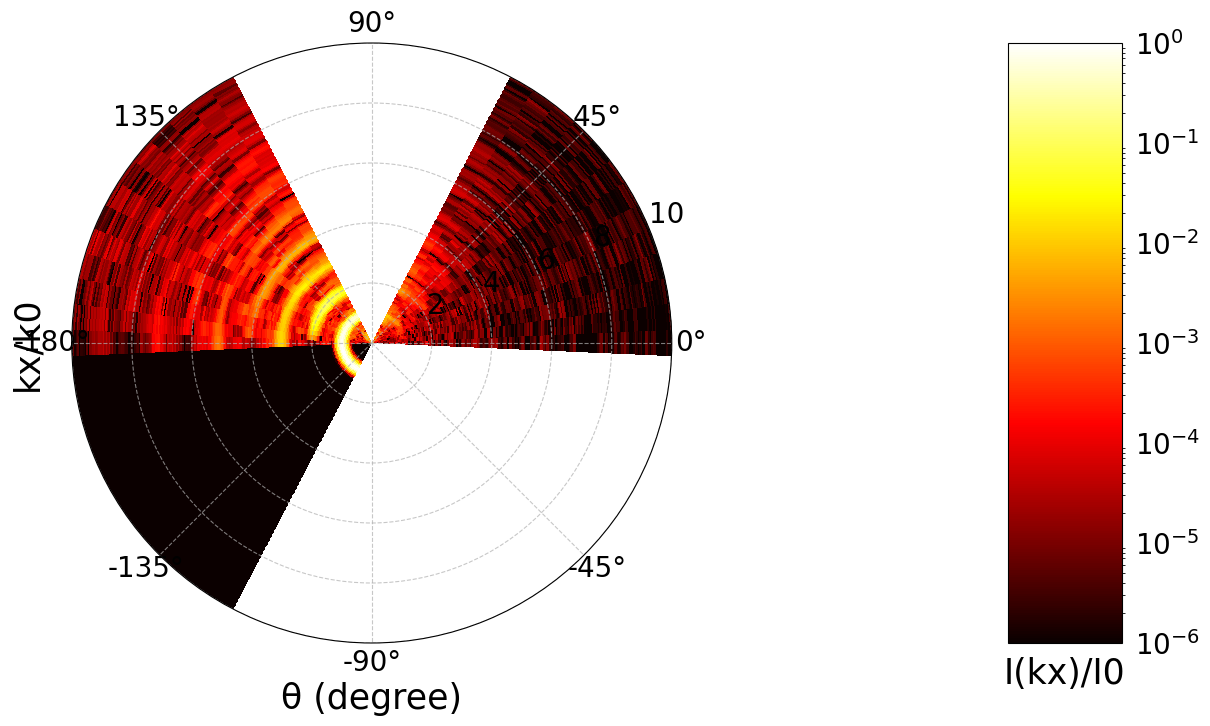

In [20]:
ax_dict=plot_polar_field(
    field=incident,
    r_coordinate=kx_coordinate,
    a_coordinate=np.radians(np.arange(0,65,5))-np.pi,
    r_label='kx/k0',
    a_label='θ (degree)',label='I(kx)/I0',
    v_min=1e-6,v_max=1,
    r_max=10,
    cmap='hot',alpha=1.0,scale='log',
    plot_colorbar=True,
)
ax_dict=plot_polar_field(
    ax_dict=ax_dict,
    field=reflection,
    r_coordinate=kx_coordinate,
    a_coordinate=-np.radians(np.arange(0,65,5))+np.pi,
    r_label='kx/k0',
    a_label='θ (degree)',label='I(kx)/I0',
    v_min=1e-6,v_max=1,
    r_max=10,
    cmap='hot',alpha=1.0,scale='log',
    plot_colorbar=False,
)
ax_dict=plot_polar_field(
    ax_dict=ax_dict,
    field=transmission,
    r_coordinate=kx_coordinate,
    a_coordinate=np.radians(np.arange(0,65,5)),
    r_label='kx/k0',
    a_label='θ (degree)',label='I(kx)/I0',
    v_min=1e-6,v_max=1,
    r_max=10,
    cmap='hot',alpha=1.0,scale='log',
    plot_colorbar=False,
)